## Sector selection

This notebook compares five European sector ETFs.

The sectors are chosen to approximate broad economic activity categories:

- Financials approximate financial and insurance activities.
- Utilities approximate electricity, gas, and regulated energy infrastructure.
- Technology approximates information and communication.
- Industrials approximate part of the manufacturing economy.
- Construction & Materials approximate the construction sector.

The mapping is not perfect because ETFs follow financial market sector classifications, while economic activity categories follow real-economy classifications. The purpose of this notebook is therefore not to reproduce official economic sector data, but to compare investable European sector exposures.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
sector_etfs = {
    "Financials": "ESIF.DE",
    "Industrials": "EXH4.DE",
    "Utilities": "EXH9.DE",
    "Technology": "EXV3.DE",
    "Construction & Materials": "EXV8.DE"
}

start_date = "2015-01-01"
end_date = "2026-07-10"

In [3]:
prices = yf.download(
    list(sector_etfs.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.rename(columns={v: k for k, v in sector_etfs.items()})

prices = prices.dropna()

prices.head()

Ticker,Financials,Industrials,Utilities,Technology,Construction & Materials
Date,,,,,
2020-11-18,5.05477,56.565861,31.158560,52.449726,47.085941
2020-11-19,4.99724,56.169006,31.120823,52.303627,46.590397
2020-11-20,5.00400,56.667389,31.468805,52.722443,46.691341
2020-11-23,5.03600,56.778137,31.187902,52.323109,46.572041
2020-11-24,5.13900,57.018089,31.225641,52.576347,47.186882


In [4]:
prices = yf.download(
    list(sector_etfs.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.rename(columns={v: k for k, v in sector_etfs.items()})

prices = prices.dropna()

prices.head()

Ticker,Financials,Industrials,Utilities,Technology,Construction & Materials
Date,,,,,
2020-11-18,5.05477,56.565861,31.158560,52.449726,47.085941
2020-11-19,4.99724,56.169006,31.120823,52.303627,46.590397
2020-11-20,5.00400,56.667389,31.468805,52.722443,46.691341
2020-11-23,5.03600,56.778137,31.187902,52.323109,46.572041
2020-11-24,5.13900,57.018089,31.225641,52.576347,47.186882


In [5]:
print("Start date:", prices.index.min())
print("End date:", prices.index.max())
print("Number of observations:", len(prices))

prices.isna().sum()

Start date: 2020-11-18 00:00:00
End date: 2026-07-09 00:00:00
Number of observations: 1434


Ticker
Financials                  0
Industrials                 0
Utilities                   0
Technology                  0
Construction & Materials    0
dtype: int64

In [6]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,Financials,Industrials,Utilities,Technology,Construction & Materials
Date,,,,,
2020-11-19,-0.011381,-0.007016,-0.001211,-0.002786,-0.010524
2020-11-20,0.001353,0.008873,0.011182,0.008007,0.002167
2020-11-23,0.006395,0.001954,-0.008926,-0.007574,-0.002555
2020-11-24,0.020453,0.004226,0.001210,0.004840,0.013202
2020-11-25,0.010313,-0.005180,0.008861,0.003890,-0.002139


In [7]:
wealth = (1 + returns).cumprod()

wealth.head()

Ticker,Financials,Industrials,Utilities,Technology,Construction & Materials
Date,,,,,
2020-11-19,0.988619,0.992984,0.998789,0.997214,0.989476
2020-11-20,0.989956,1.001795,1.009957,1.005200,0.991620
2020-11-23,0.996287,1.003753,1.000942,0.997586,0.989086
2020-11-24,1.016663,1.007995,1.002153,1.002414,1.002144
2020-11-25,1.027149,1.002774,1.011033,1.006314,1.000000


In [8]:
# Daily returns
returns = prices.pct_change().dropna()

# Cumulative performance
wealth = (1 + returns).cumprod()

# Volatility
daily_volatility = returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)

# Drawdowns
running_peak = wealth.cummax()
drawdowns = wealth / running_peak - 1
max_drawdown = drawdowns.min()

# Summary Table

In [9]:
summary = pd.DataFrame({
    "Cumulative Return": wealth.iloc[-1] - 1,
    "Annualized Volatility": annualized_volatility,
    "Maximum Drawdown": max_drawdown
})

summary = summary * 100

summary

,Cumulative Return,Annualized Volatility,Maximum Drawdown
Ticker,,,
Financials,227.294825,18.822053,-22.932069
Industrials,107.581033,19.296205,-31.072188
Utilities,88.327062,15.997416,-22.705127
Technology,85.434719,24.711104,-40.289941
Construction & Materials,86.594975,19.200235,-29.232429


# Wealth Chart

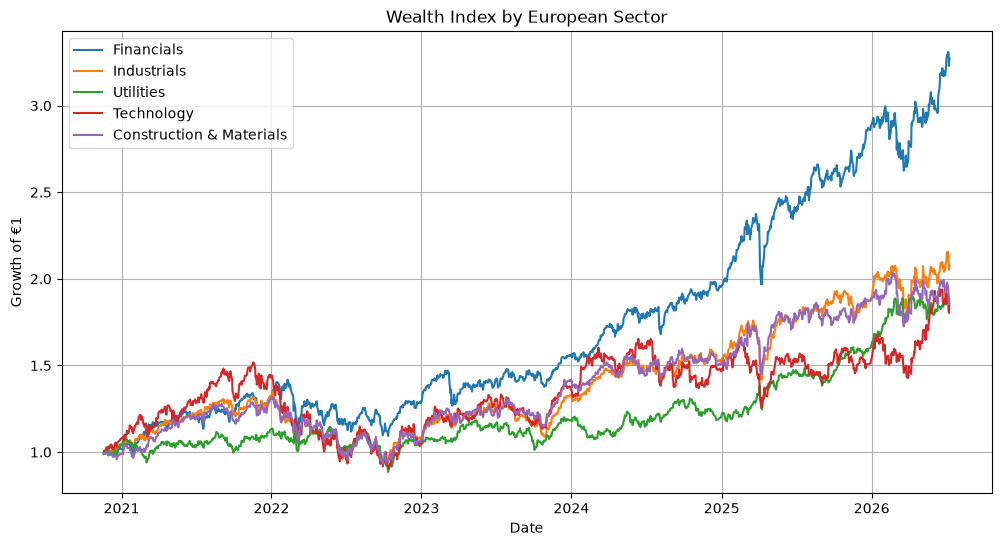

In [10]:
plt.figure(figsize=(12, 6))

for sector in wealth.columns:
    plt.plot(wealth.index, wealth[sector], label=sector)

plt.title("Wealth Index by European Sector")
plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.grid(True)
plt.legend()
plt.show()

# Annualized volatility

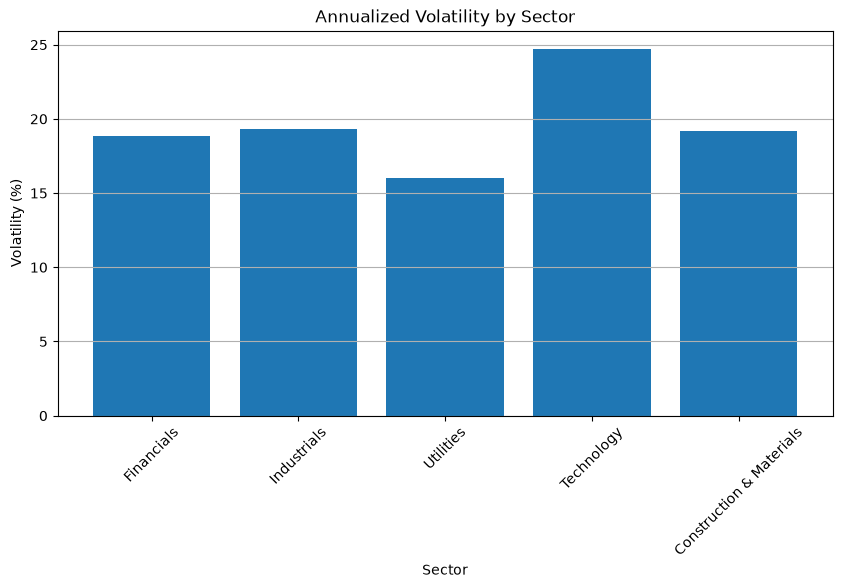

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(summary.index, summary["Annualized Volatility"])

plt.title("Annualized Volatility by Sector")
plt.xlabel("Sector")
plt.ylabel("Volatility (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# Drawdowns

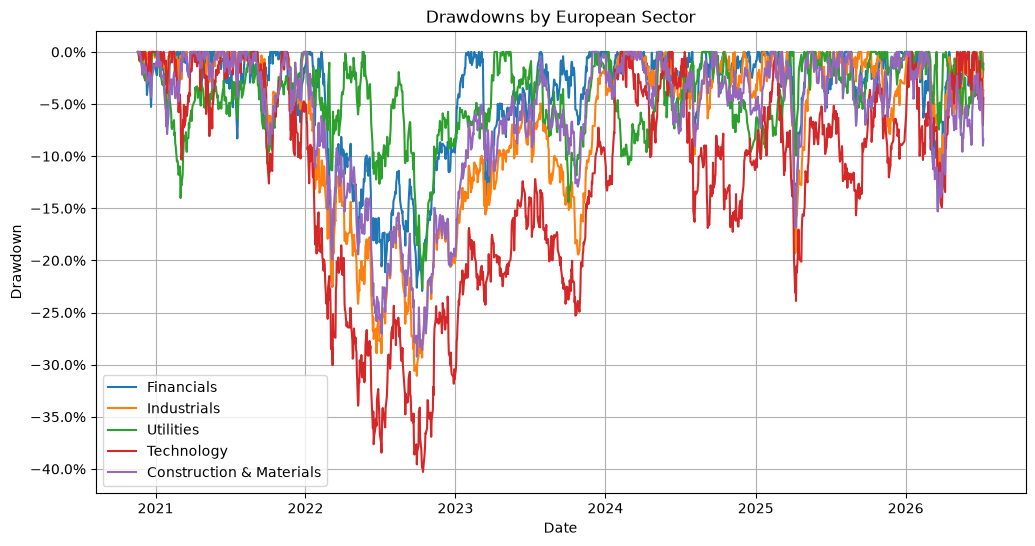

In [12]:
plt.figure(figsize=(12, 6))

for sector in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[sector], label=sector)

plt.title("Drawdowns by European Sector")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.legend()
plt.show()

## Risk-return-drawdown map

This chart combines the three main concepts of the notebook into one view.

- The vertical axis shows cumulative return.
- The horizontal axis shows annualized volatility.
- The bubble size shows maximum drawdown.

A better historical profile is generally higher, further left, and smaller.
This means higher return, lower volatility, and lower maximum drawdown.

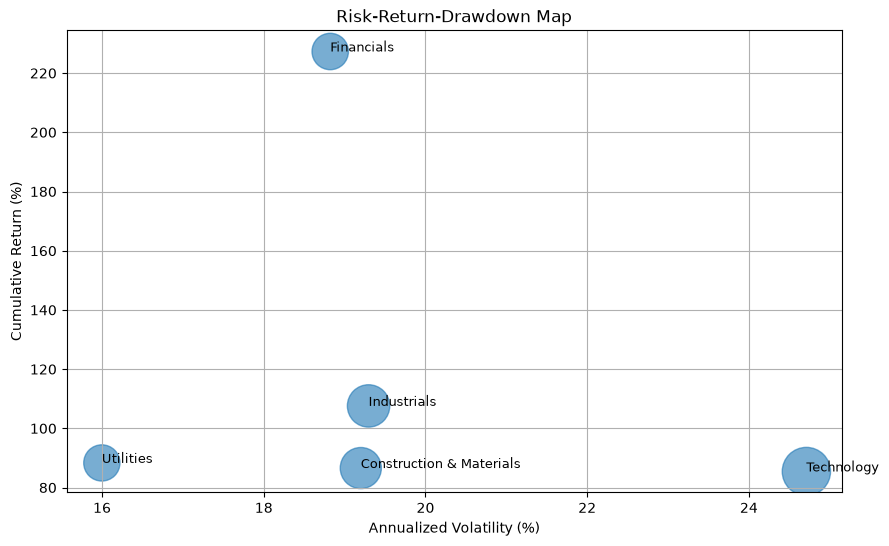

In [13]:
# Prepare data for the combined chart
plot_data = summary.copy()

# Maximum drawdown is negative, so we use its absolute value for bubble size
plot_data["Drawdown Size"] = plot_data["Maximum Drawdown"].abs()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["Annualized Volatility"],
    plot_data["Cumulative Return"],
    s=plot_data["Drawdown Size"] * 30,
    alpha=0.6
)

# Add sector names next to each point
for sector in plot_data.index:
    plt.text(
        plot_data.loc[sector, "Annualized Volatility"],
        plot_data.loc[sector, "Cumulative Return"],
        sector,
        fontsize=9
    )

plt.title("Risk-Return-Drawdown Map")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Cumulative Return (%)")
plt.grid(True)

plt.show()

## 3D risk-return-drawdown map

This chart places each sector in a three-dimensional risk-performance space.

- X-axis: annualized volatility
- Y-axis: cumulative return
- Z-axis: absolute maximum drawdown

The ideal historical profile would have high cumulative return, low volatility, and low maximum drawdown.

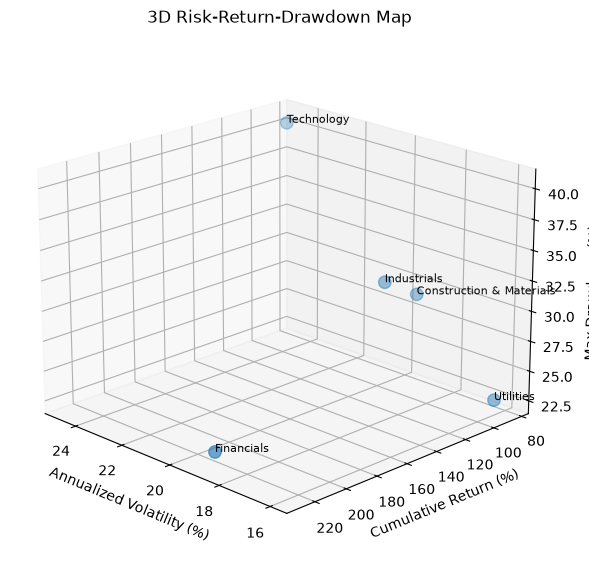

In [14]:
# Prepare data for the 3D chart
plot_data = summary.copy()

# Maximum drawdown is negative, so we convert it into a positive size
plot_data["Absolute Maximum Drawdown"] = plot_data["Maximum Drawdown"].abs()

# Create 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# 3D scatter plot
ax.scatter(
    plot_data["Annualized Volatility"],
    plot_data["Cumulative Return"],
    plot_data["Absolute Maximum Drawdown"],
    s=80,
    alpha=0.8
)

# Add sector labels
for sector in plot_data.index:
    ax.text(
        plot_data.loc[sector, "Annualized Volatility"],
        plot_data.loc[sector, "Cumulative Return"],
        plot_data.loc[sector, "Absolute Maximum Drawdown"],
        sector,
        fontsize=8
    )

# Labels and title
ax.set_title("3D Risk-Return-Drawdown Map")
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Cumulative Return (%)")
ax.set_zlabel("Max Drawdown (%)")

# Adjust viewing angle
ax.view_init(elev=20, azim=135)

plt.show()